# Análise Exploratória dos Dados

[...]

## Importando as Bibliotecas

Primeiramente vamos importar nossas bibliotecas.

In [106]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

## Carregando o Dataset

Agora, vamos carregar nosso dataset que já passou pelo processo de limpeza.

In [107]:
df = pd.read_parquet("../data/processed/UCMF_cleaned.parquet")

# Análise de Valores Faltantes

Vamos inicialmente analisar os valores faltantes do nosso dataset. Primeiro vamos detectar eles em nosso dataset.

In [108]:
df_na_count = df.isna().sum()
total = df.shape[0]

df_missing = pd.DataFrame({
    "Contagem de NA": df_na_count,
    "Porcentagem": (100*df_na_count / total).round(2),
})

df_missing

,Contagem de NA,Porcentagem
id,0,0.00
peso,2928,22.75
altura,4460,34.65
imc,4836,37.57
atendimento,1296,10.07
nascimento,1631,12.67
idade,1618,12.57
convenio,4108,31.91
pulsos,1194,9.28
pa_sistolica,7730,60.05


Como podemos ver, temos valores faltantes em todas as features, exceto em `"id"`. Além disso temos valores faltantes até mesmo no target, o que é uma situação um pouco incomum. Primeiramente vamos lidar com os valores faltantes no target removendo eles, pois eles não trazem informação alguma para nosso modelo supervisionado.

In [109]:
df = df.dropna(subset="patologia")

In [110]:
df.info()

<class 'pandas.DataFrame'>
Index: 11705 entries, 0 to 12872
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             11705 non-null  Int64         
 1   peso           9587 non-null   Float64       
 2   altura         8078 non-null   Int64         
 3   imc            7708 non-null   Int64         
 4   atendimento    11174 non-null  datetime64[us]
 5   nascimento     10855 non-null  datetime64[us]
 6   idade          10865 non-null  Float64       
 7   convenio       8379 non-null   category      
 8   pulsos         11657 non-null  category      
 9   pa_sistolica   5131 non-null   Int64         
 10  pa_diastolica  5121 non-null   Int64         
 11  ppa            10768 non-null  category      
 12  patologia      11705 non-null  category      
 13  b2             11674 non-null  category      
 14  sopro          11682 non-null  category      
 15  fc             10986 non-null  Int6

### Investigando os Valores Faltantes

Agora vamos investigar se esses valores faltantes trazem alguma informação relevante para o nosso target. Primeiro vamos criar algumas visualizações importantes dos nossos valores faltantes. A primeira visualização que iremos analisar é o padrão nos valores faltantes em cada feature.

<Axes: >

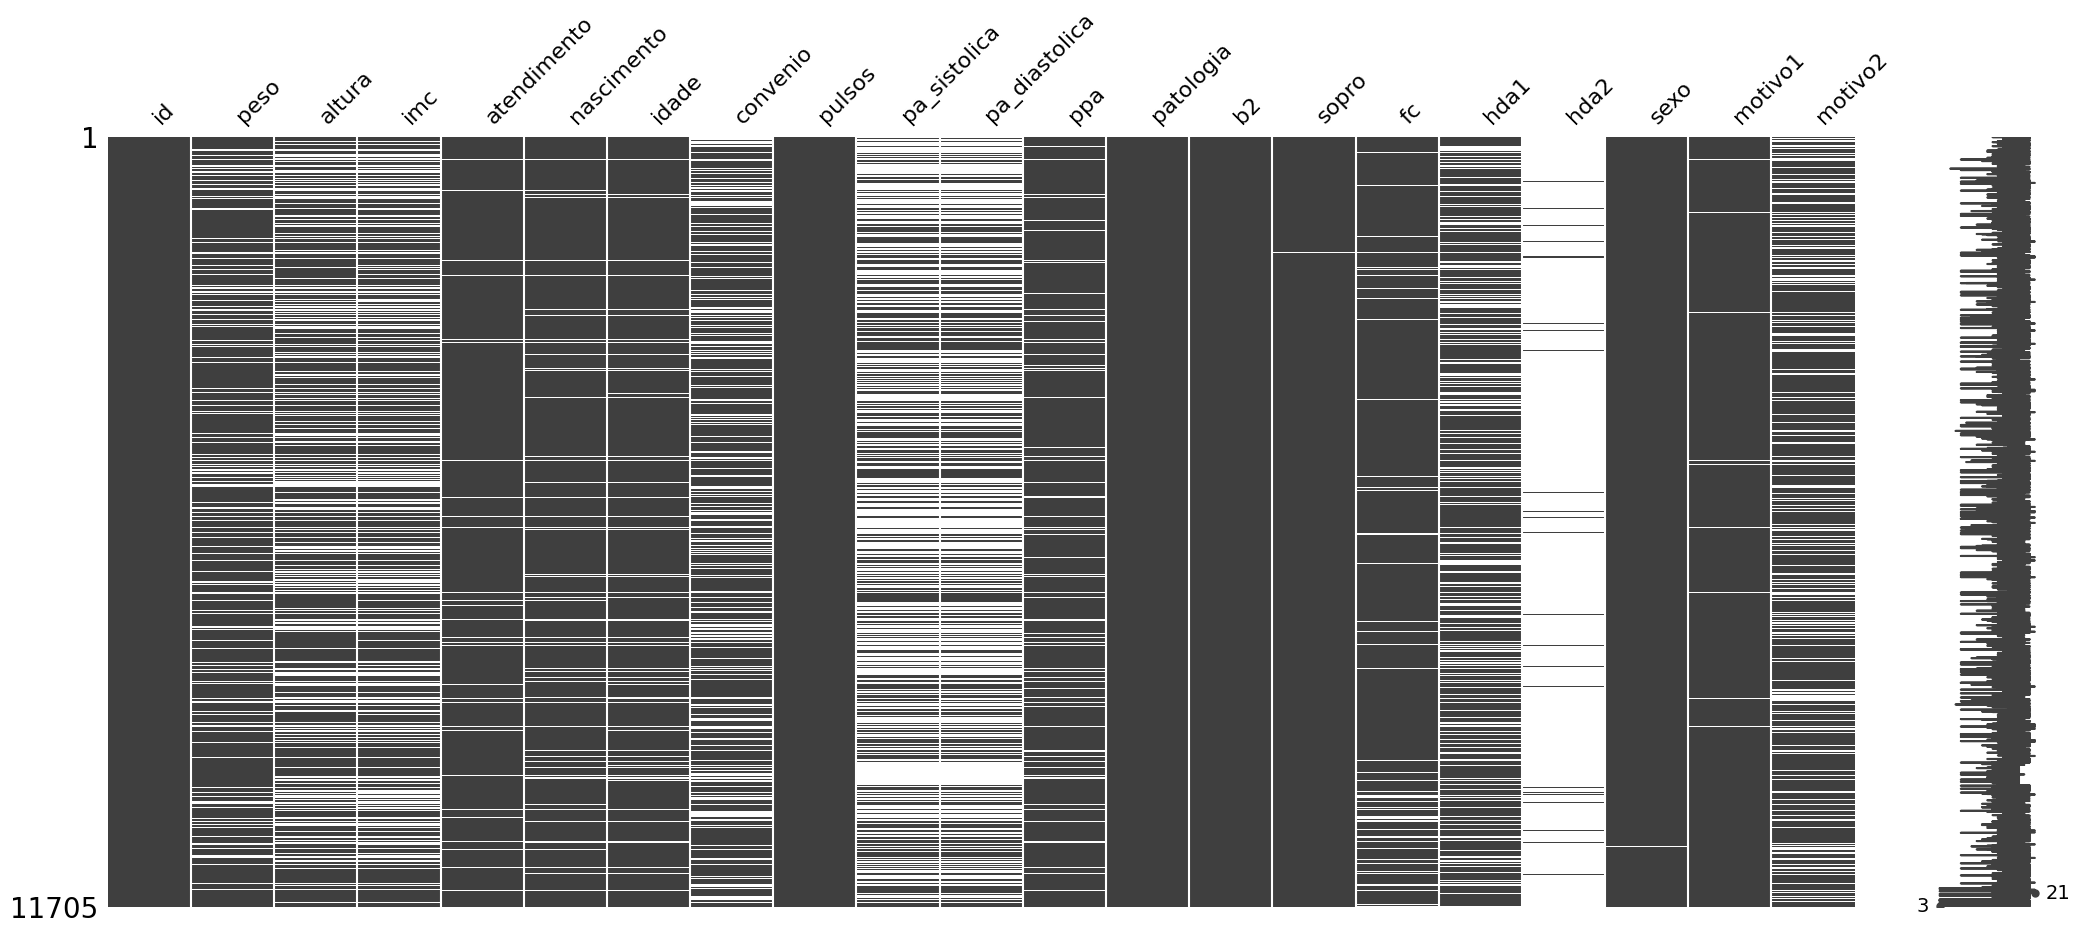

In [111]:
msno.matrix(df)

Como podemos ver alguns pares de features apresentam um padrão parecido nos valores faltantes, sendo eles os seguintes pares: (`"altura"`, `"imc"`), (`"nascimento"`, `"idade"`) e (`"pa_sistolica"`, `"pa_diastolica"`). No primeiro caso faz sentido pois o $\text{IMC}$ é calculado a partir do peso e da altura, portanto se eu tenho dados faltantes em um dos dois então eu tenho dados faltantes no $\text{IMC}$. O mesmo argumento é usado no caso do nascimento e da idade. Por fim, o último caso ocorre porque ao medirmos a pressão sanguínea temos que medir tanto a sistólica quanto a diastólica, então se uma das duas não foi coletada então a outra também não foi. As demais features parecem ter valores faltantes aleatórios, portanto podemos analisar as correlações entre eles.

<Axes: >

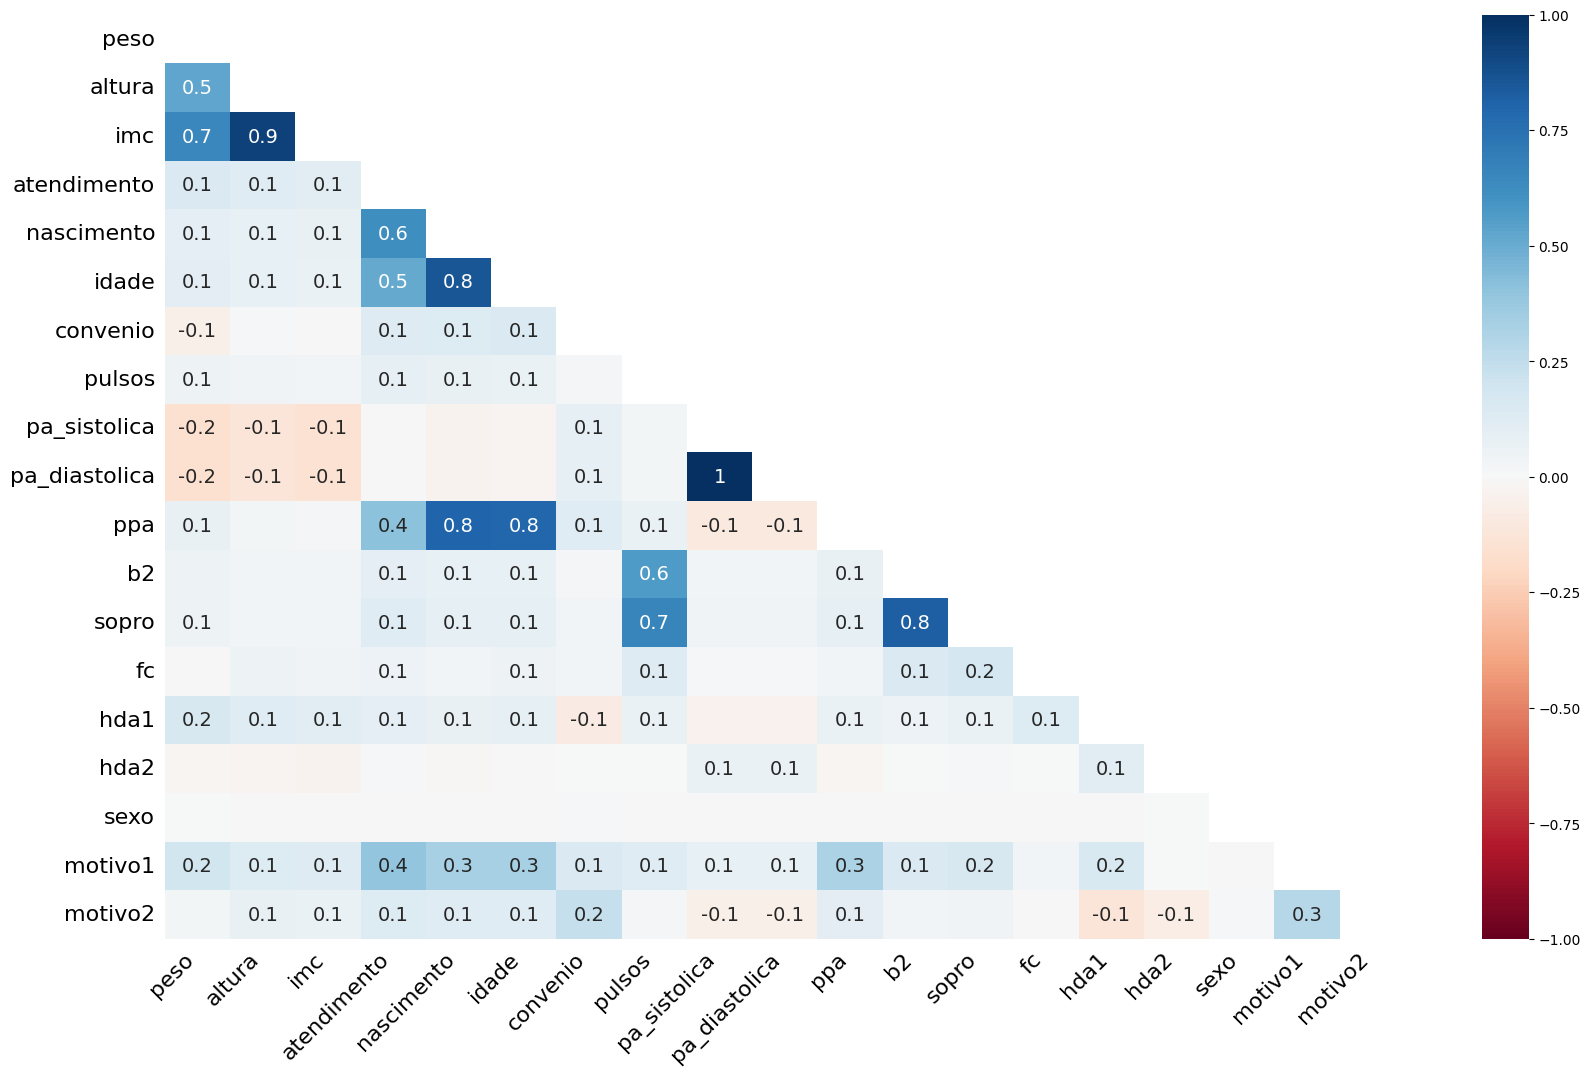

In [112]:
msno.heatmap(df)

Com essa matriz de correlação podemos confirmar nossa observação anterior e adicionar mais alguns pares correlacionados, sendo eles: (`"peso"`, `"imc"`), (`"ppa"`, `"idade"`), (`"ppa"`, `"nascimento"`) e (`"b2"`, `"sopro"`). Agora só para confirmar essas observações, vamos olhar os agrupamentos dessas features baseados nos valores faltantes.

<Axes: >

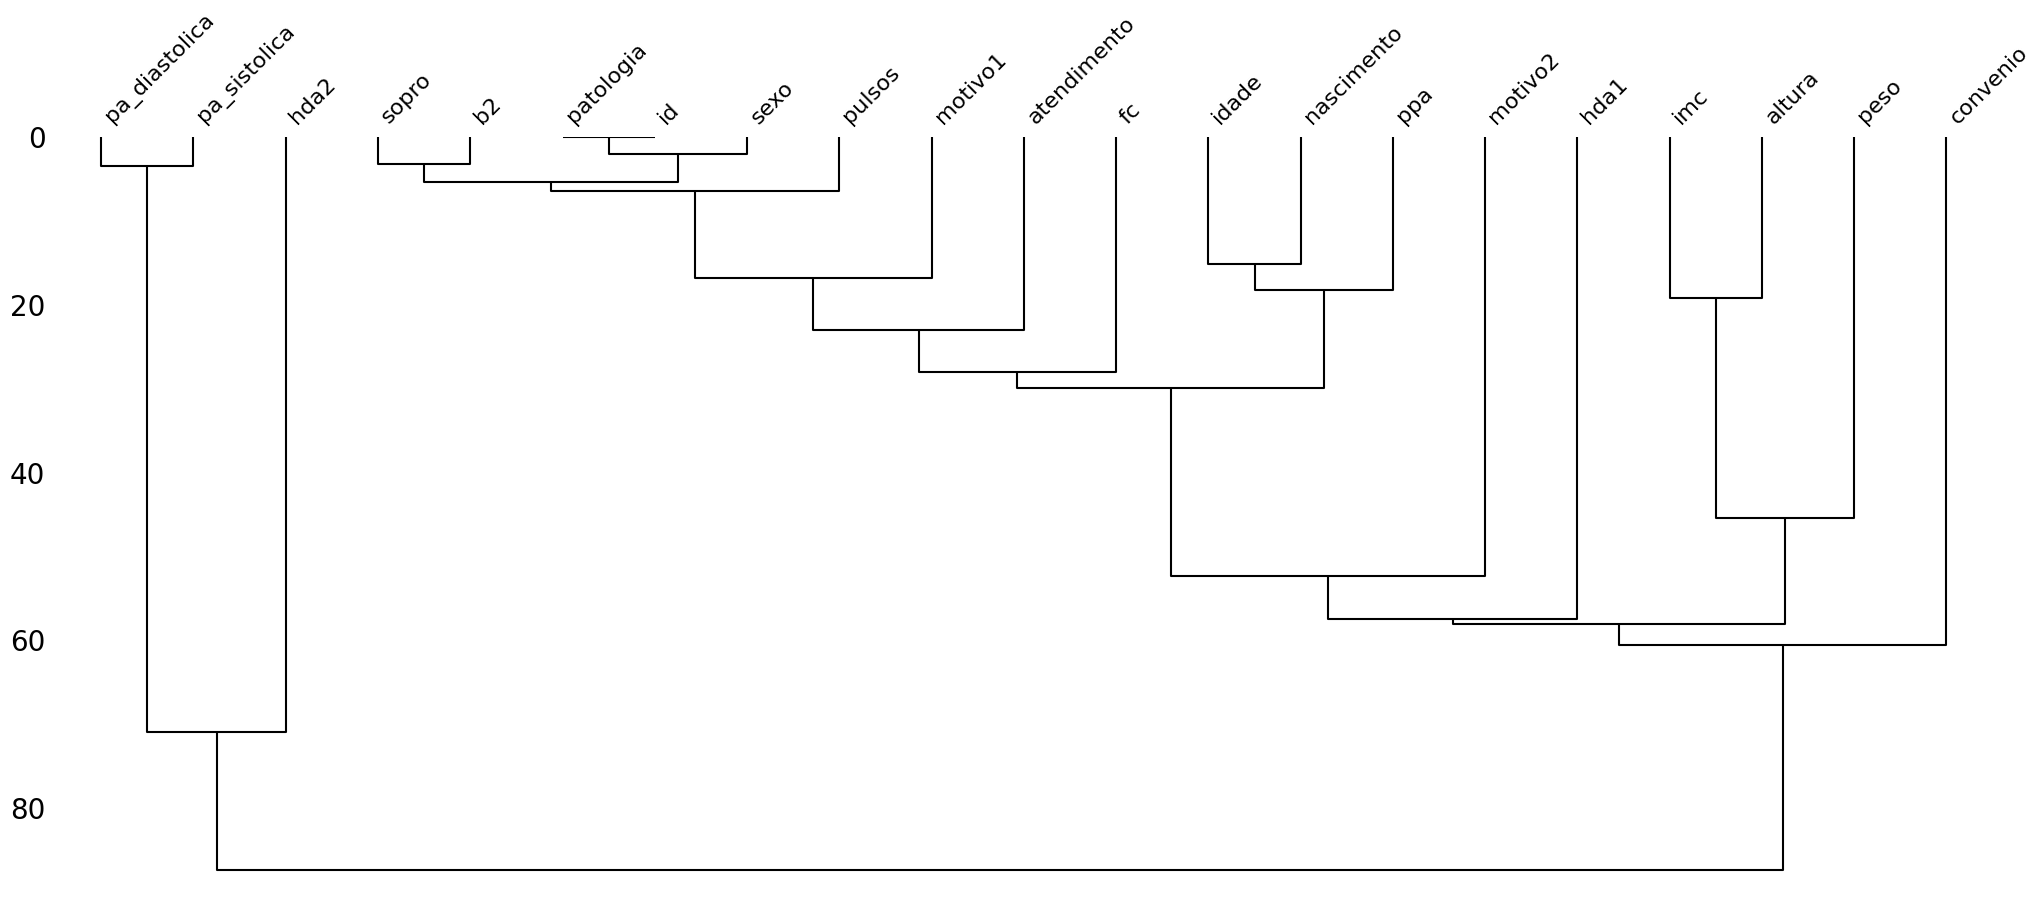

In [113]:
msno.dendrogram(df)

Com isso fica confirmado nossas observações. Agora vamos analisar a relação entre os dados faltantes e nosso target. Para isso primeiro iremos criar um dataframe missing indicator, ou seja, um dataframe idêntico ao original mas com valores `True` ou `False` indicando que o valor subjacente está faltando ou não no dataframe original. Com esse dataframe iremos treinar um modelo de Random Forest com validação cruzada estratificada e checaremos o desempenho do modelo para determinarmos se os valores faltantes têm informação sobre o target ou não. Dessa forma poderemos saber como lidar com os valores faltantes.

In [114]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

df_missing = df.isna().astype(int)

X = df_missing.drop("patologia", axis="columns")
y = df["patologia"].map({"ausente": 1, "presente": 0}).astype(int)

random_state = 42

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

model = RandomForestClassifier(
    random_state=random_state
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print(f"ROC-AUC: {100*scores.mean()}%")
print(f"STD:     {scores.std()}")

ROC-AUC: 62.96766272507711%
STD:     0.010915450384894691


Como podemos ver, o $\text{ROC-AUC}$ foi de $62\%$. Esse valor é baixo mas ainda assim indica que os valores faltantes podem estar carregando informação relevante sobre o target. Por isso vamos treinar um modelo de Regressão Logística para sabermos as odds de cada feature em relação ao target. Além disso vamos olhar para as porcentagens de missing para termos uma noção melhor dos nossos dados.

In [115]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=random_state
)

model.fit(X, y)

missing_info = pd.DataFrame({
    "odds": np.exp(model.coef_)[0],
    "perc": 100*X.mean(),
}).round(2).sort_values(by="odds")

missing_info

,odds,perc
pulsos,0.54,0.41
fc,0.65,6.14
pa_diastolica,0.68,56.25
imc,0.71,34.15
nascimento,0.74,7.26
b2,0.77,0.26
convenio,0.81,28.42
ppa,0.95,8.01
pa_sistolica,0.97,56.16
id,1.00,0.00


Agora com essas informações podemos agrupar as features da seguinte forma:

- **Grupo A**: Forte Efeito Positivo
  - sopro
  - motivo2
  - hda1
  - atendimento
  - altura
  - sexo
- **Grupo B**: Forte Efeito Negativo
  - pulsos
  - fc
  - pa_diastolica
  - imc
  - nascimento
  - b2
  - convenio
- **Grupo C**: Nenhum Efeito
  - ppa
  - pa_sistolica
  - id
  - motivo1
  - hda2
  - peso
  - idade

O grupo A corresponde às features em que a presença do missing aumenta bastante as chances da classe positiva. Já o grupo B diminui as chances da classe negativa. Por fim, o grupo C tem baixo efeito na classe positiva. Agora vamos ignorar o grupo C e olhar para as features que possuem mais que $20\%$ de missing.

- **Grupo A**: Forte Efeito Positivo
  - motivo2
  - hda1
  - altura
- **Grupo B**: Forte Efeito Negativo
  - pa_diastolica
  - imc
  - convenio

Essas features têm forte efeito nas odds da classe positiva e possuem uma taxa razoável de missing, portanto criaremos indicadores de missing para essas variáveis.

In [116]:
cols = [
    "motivo2",
    "hda1",
    "altura",
    "pa_diastolica",
    "imc",
    "convenio"
]

for col in cols:
    df[f"{col}_faltante"] = df[col].isna().astype("boolean")

df.head()

,id,peso,altura,imc,atendimento,nascimento,idade,convenio,pulsos,pa_sistolica,...,hda2,sexo,motivo1,motivo2,motivo2_faltante,hda1_faltante,altura_faltante,pa_diastolica_faltante,imc_faltante,convenio_faltante
0,1,5.0,51,19,2006-05-11,2006-03-30,0.12,gs,normais,<NA>,...,NaN,masculino,suspeita_de_cardiopatia,palpitacao/taquicardia/arritmia,False,False,False,True,False,False
1,2,3.5,50,14,2005-05-25,2005-05-19,0.02,gs,normais,<NA>,...,NaN,masculino,suspeita_de_cardiopatia,dispneia,False,False,False,True,False,False
2,3,<NA>,<NA>,<NA>,2001-06-12,2005-05-08,<NA>,sula,normais,<NA>,...,NaN,masculino,check_up,NaN,True,False,True,True,True,False
3,4,8.1,65,19,2009-10-15,2009-04-21,0.5,NaN,normais,<NA>,...,NaN,masculino,parecer_cardiologico,NaN,True,False,False,True,False,True
4,7,40.0,151,18,2008-01-14,1995-08-14,12.89,same,normais,<NA>,...,NaN,masculino,parecer_cardiologico,NaN,True,False,False,True,False,False


In [117]:
df.info()

<class 'pandas.DataFrame'>
Index: 11705 entries, 0 to 12872
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      11705 non-null  Int64         
 1   peso                    9587 non-null   Float64       
 2   altura                  8078 non-null   Int64         
 3   imc                     7708 non-null   Int64         
 4   atendimento             11174 non-null  datetime64[us]
 5   nascimento              10855 non-null  datetime64[us]
 6   idade                   10865 non-null  Float64       
 7   convenio                8379 non-null   category      
 8   pulsos                  11657 non-null  category      
 9   pa_sistolica            5131 non-null   Int64         
 10  pa_diastolica           5121 non-null   Int64         
 11  ppa                     10768 non-null  category      
 12  patologia               11705 non-null  category      
 13  b2

Agora, precisamos fazer algumas considerações importantes sobre esse dataset. O primeiro é que os valores faltantes nesse dataset podem ter algumas causas específicas, por exemplo, variáveis como `"pulsos"` e `"pa_sistolica"` podem estar faltando porque não foram medidas e não porque o valor não existe, até porque em ambos o valor existe. Já no caso do `"hda2"` o valor faltante pode simplesmente indicar que o paciente não teve um segundo histórico de doença (um argumento parecido pode ser usado para o `"motivo2"`). Além disso no caso do `"hda2"`, se não houver o primeiro histórico (`"hda1"`) não faz sentido ter um segundo histórico e isso é confirmado no código a seguir.

In [118]:
mask_1 = (X["hda1"] == True)
mask_2 = (X["hda2"] == False)

X[mask_1 & mask_2]

,id,peso,altura,imc,atendimento,nascimento,idade,convenio,pulsos,pa_sistolica,pa_diastolica,ppa,b2,sopro,fc,hda1,hda2,sexo,motivo1,motivo2
147,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0


Como podemos ver, apenas um único registro possui um segundo histórico sem ter um primeiro. Isso indica que ambas as features possuem essa regra de negócio e portanto pode ser perigoso imputar valores em `"hda2"` pois isso pode acabar matando a informação de que o segundo histórico não foi preenchido porque não existia. E como citado anteriormente, isso também pode ocorrer com a feature `"motivo2"`. Dessa forma, podemos olhar para essas duas features `"hda2"` e `"motivo2"` com carinho e considerar que seus valores faltantes ocorre mais pela inexistência do valor em si e do que pelo fato dele não ter sido registrado. Portanto para ambos os casos iremos criar uma nova categoria que represente essa ausência e preencher todos os valores faltantes por essa categoria.

In [119]:
cols = ["motivo2", "hda2"]
na_cat = "nao_aplicavel"

for col in cols:
    df[col] = df[col].cat.add_categories(na_cat)
    df[col] = df[col].fillna(na_cat)

df.info()

<class 'pandas.DataFrame'>
Index: 11705 entries, 0 to 12872
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      11705 non-null  Int64         
 1   peso                    9587 non-null   Float64       
 2   altura                  8078 non-null   Int64         
 3   imc                     7708 non-null   Int64         
 4   atendimento             11174 non-null  datetime64[us]
 5   nascimento              10855 non-null  datetime64[us]
 6   idade                   10865 non-null  Float64       
 7   convenio                8379 non-null   category      
 8   pulsos                  11657 non-null  category      
 9   pa_sistolica            5131 non-null   Int64         
 10  pa_diastolica           5121 non-null   Int64         
 11  ppa                     10768 non-null  category      
 12  patologia               11705 non-null  category      
 13  b2

Nessa etapa do processo não faremos imputação nos valores faltantes, pois deixaremos para fazer isso no pipeline individual de cada modelo que iremos treinar.

## Análise de Correlação

Vamos analisar a correlação entre as variáveis do nosso dataset. Isso nos ajudará a diagnosticar possíveis data leakeages futuros.

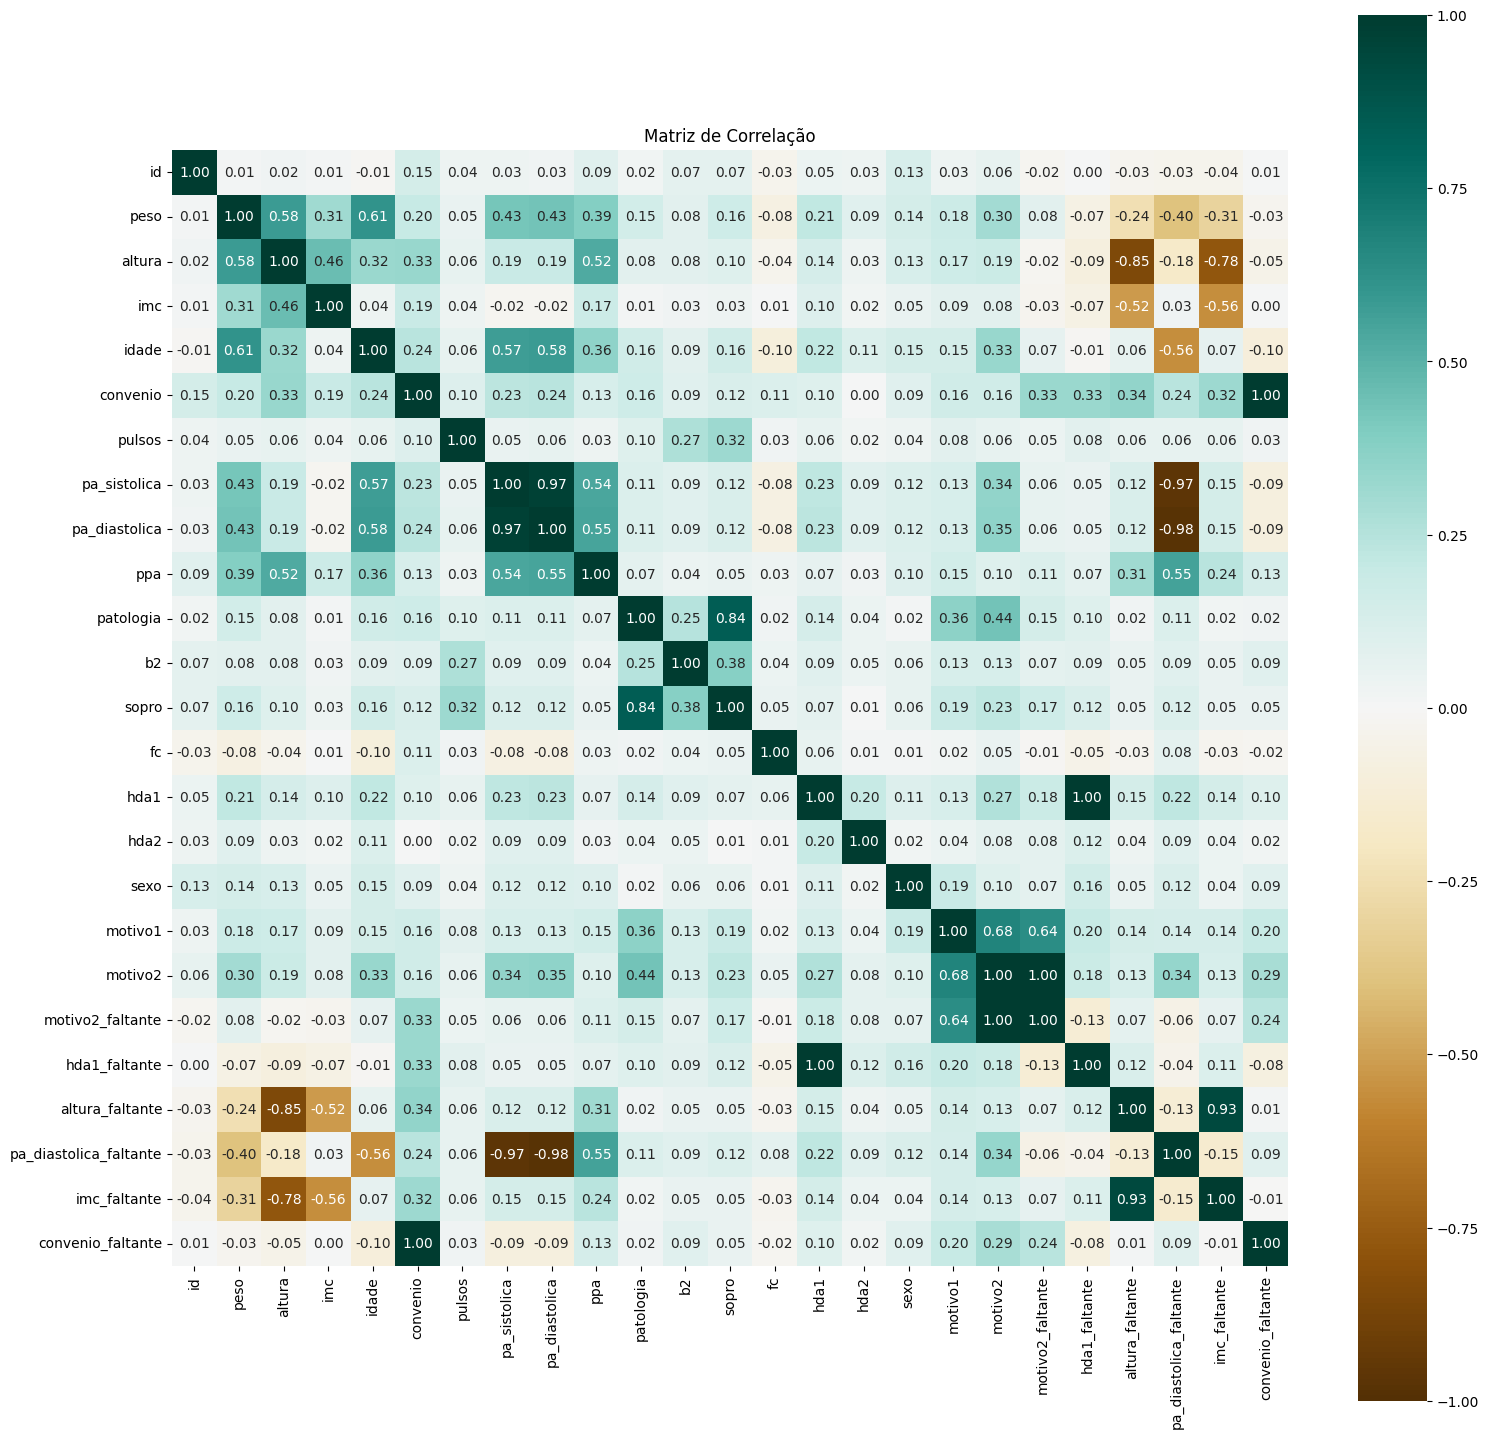

In [120]:
from dython.nominal import associations

df_heatmap = df.drop(["nascimento", "atendimento"], axis="columns")

assoc = associations(
    df_heatmap,
    figsize=(18, 18),
    cmap="BrBG",
    title="Matriz de Correlação"
)

Como podemos ver temos algumas correlações altas entre alguns pares de variáveis, mas uma chama atenção: a correlação entre `"patologia"` e `"sopro"`. Essa correlação é especialmente relevante pois os modelos que iremos treinar podem aprender erroneamente que a predição do valor de `"patologia"` pode ser obtida pela variável `"sopro"`, o que nós conhecemos como data leakage. Dessa forma devemos ficar atentos a essa variável quando formos treinar nossos modelos. Não iremos remover essa feature pois ainda não sabemos se ela vai causar data leakage, vamos analisar isso melhor quando formos treinar nossos modelos.

## Análise de Outliers

Para analisar possíveis outliers no nosso dataset vamos inicialmente computar alguns boxplots e violin plots de cada variável numéricas para identificar inicialmente a presença de outliers.

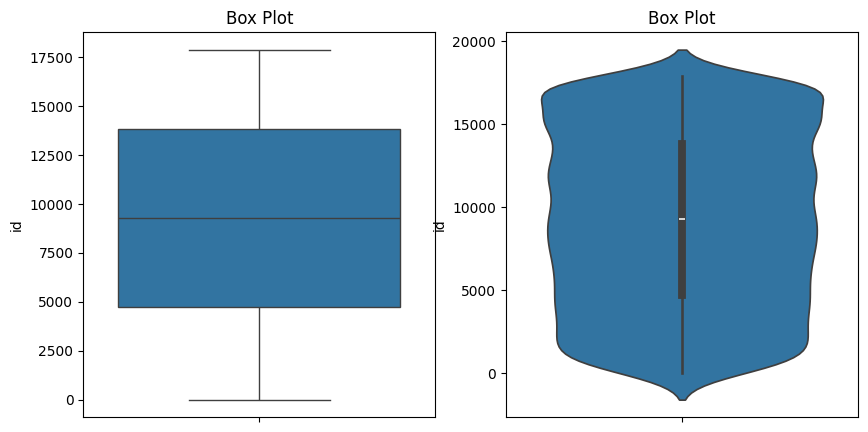

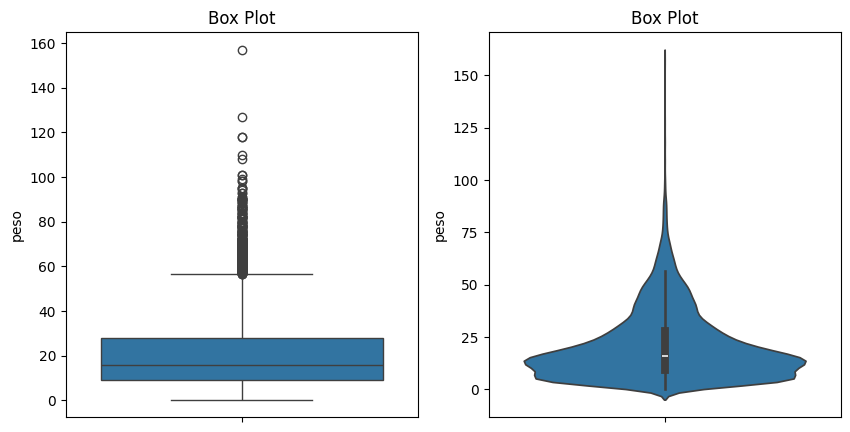

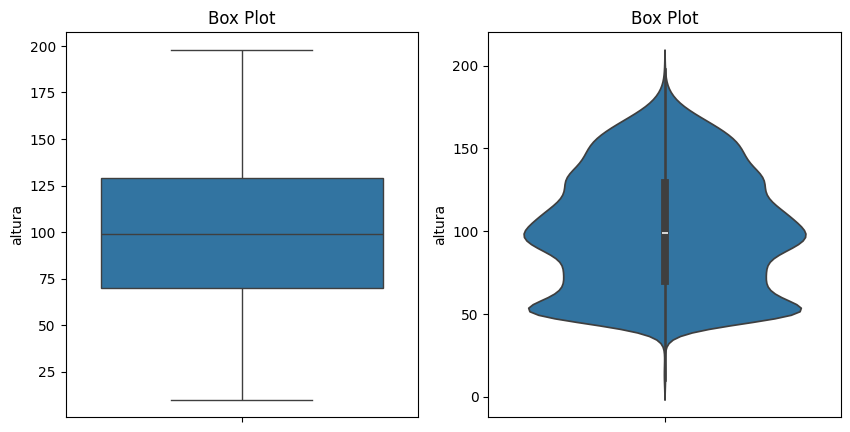

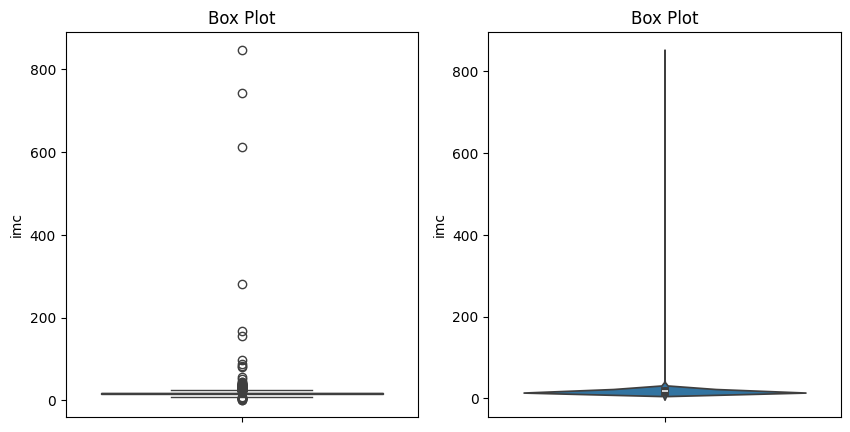

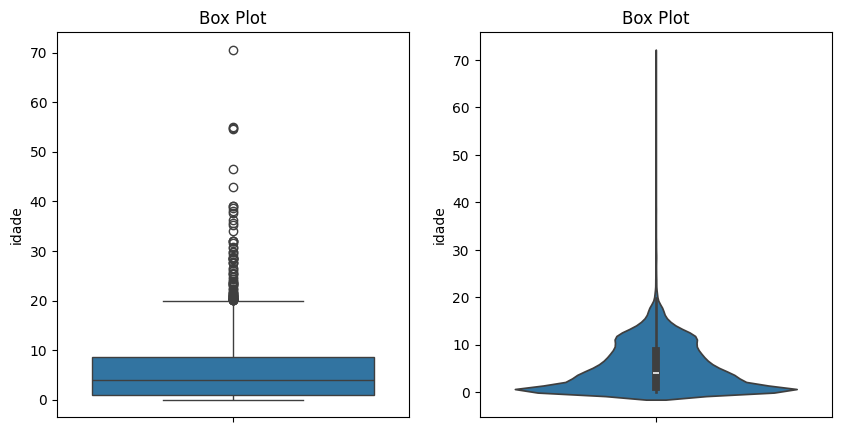

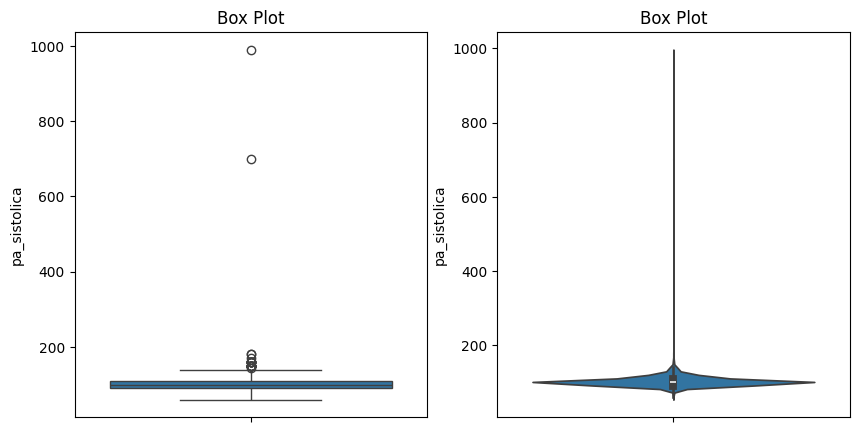

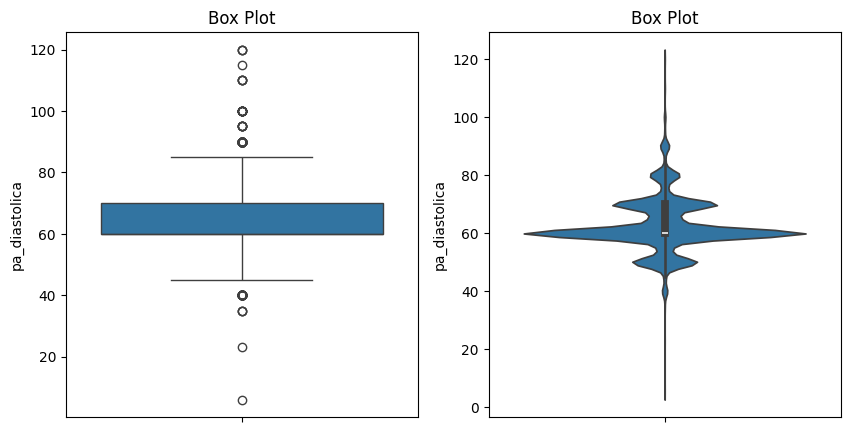

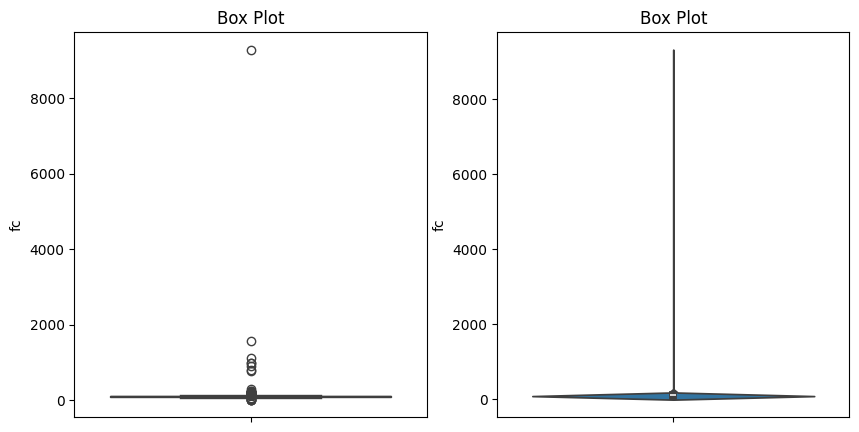

In [121]:
df_num = df.select_dtypes(include="number")

for col in df_num.columns:
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    sns.boxplot(
        y=df_num[col],
        ax=ax[0]
    )

    ax[0].set_title("Box Plot")

    sns.violinplot(
        y=df_num[col],
        ax=ax[1]
    )

    ax[1].set_title("Box Plot")


Como podemos ver, temos alguns outliers nas variáveis `"peso"`, `"imc"`, `"idade"`, `"pa_sistolica"`, `"pa_diastolica"` e `"fc"`. Vamos analisar cada uma dessas variáveis e checar quantos outliers (via IQR) nós temos.

In [122]:
from scipy.stats import iqr

cols = [
    "peso",
    "imc",
    "idade",
    "pa_sistolica",
    "pa_diastolica",
    "fc"
]

for col in cols:
    x = df[col].dropna()

    IQR = iqr(x)

    LI = np.quantile(x, 0.25) - 1.5*IQR
    LS = np.quantile(x, 0.75) + 1.5*IQR

    count = ((x < LI) | (x > LS)).sum()

    print(f"Qtd. de outliers em {col}: {count}")

Qtd. de outliers em peso: 392
Qtd. de outliers em imc: 251
Qtd. de outliers em idade: 76
Qtd. de outliers em pa_sistolica: 25
Qtd. de outliers em pa_diastolica: 164
Qtd. de outliers em fc: 497


Como podemos ver, temos poucos outliers nas features numéricas, portanto manteremos esses outliers no nosso dataset.

## Salvando as Alterações

Por fim, vamos salvar nosso dataset com as mudanças feitas.

In [123]:
df.to_parquet("../data/processed/UCMF_analysed.parquet")